# Q-Learning 으로 CartPole 균형잡기

Gymnasium 의 `CartPole-v1` 환경에서 카트 위에 세워진 막대(폴) 가 쓰러지지 않도록 좌/우 행동만으로 균형을 잡는 정책을 **Q-Learning** 으로 학습합니다. 연속 상태를 작은 테이블로 이산화한 뒤 ε-greedy 탐험과 Q-Table 업데이트만으로 충분히 풀 수 있다는 것을 확인하는 실습입니다.

## 학습 목표
- Gym 환경의 `reset` / `step` / `render` 인터페이스 사용법 이해
- 연속 상태(state) 를 **State Discretization** 으로 Q-Table 인덱스로 매핑
- **ε-greedy** 정책으로 탐험(exploration) 과 이용(exploitation) 균형 잡기
- **Q-Learning 업데이트 식** $Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$ 로 테이블 갱신
- ε / learning rate 스케줄링이 학습 안정성에 미치는 영향 체감

## 사용 라이브러리
- `gym` — CartPole 환경 제공
- `numpy` — Q-Table 연산
- `matplotlib` — 환경 렌더링 시각화
- `pyvirtualdisplay`, `xvfb` — Colab 등 헤드리스 환경에서의 렌더링 지원

# Cart Pole 강화학습 연습

<img src="https://github.com/aidentify/lecture/blob/master/study2/2_RL/img/cartpole_env.png?raw=1" width="600">

## 실행 환경 안내

로컬(Jupyter) 환경에서는 Colab용 가상 디스플레이 설치가 필요 없습니다. 학습 중에는 렌더링을 끄고 빠르게 학습한 뒤, 마지막에 **학습 곡선**으로 결과를 확인합니다.

In [ ]:
# 로컬(Jupyter) 환경에서는 Colab용 가상 디스플레이(xvfb)가 필요 없습니다.
# 학습 중에는 렌더링을 끄고 빠르게 학습한 뒤, 마지막에 학습 곡선으로 결과를 확인합니다.

## 필요한 모듈 import
* gymnasium (강화학습 가상환경 제공, 구버전 gym 의 후속)
* numpy (텐서 연산)
* matplotlib (결과 그래프 출력)

In [ ]:
import gymnasium as gym   # 구버전 gym 의 후속 (API 호환 라이브러리)
import numpy as np
import matplotlib.pyplot as plt
import math

## 가상환경 설정 

* gym.make를 이용하여 등록된 'CartPole-v1' 환경을 env로 정의

In [ ]:
env = gym.make('CartPole-v1')   # gymnasium 환경 (CartPole-v1 는 deprecated)
print('상태 공간:', env.observation_space)
print('행동 공간:', env.action_space)

##  hyper parameter 정의
* learning rate init: 초기 학습률 (시간 경과에 따른 학습률을 조정하기 위해)
* discount: 감쇄계수
* num_episodes: 전체 반복 학습 횟수
* max_trial: 실패하기 전까지 반복횟수
* num_success: 1차 학습 완료까지 기준
* streak_num_success: 1차성공 (199번 반복시까지 실패가 없을 경우)이 연속된 횟수
* status_check: 진행상황 확인 (IF TRUE)

In [ ]:
# ===== 하이퍼파라미터 =====
gamma = 0.99             # 감쇄계수 (미래 보상 가중치)
num_episodes = 300       # 전체 학습 에피소드 수
max_trial = 500          # 한 에피소드 최대 step (CartPole-v1 한계)
num_success = 195        # 성공으로 인정할 step 수
streak_num_success = 100 # 연속 성공 목표

# 학습률/탐험률은 에피소드에 따라 자동 감소
min_rate = 0.1
def get_rate(episode):
    return max(min_rate, min(1.0, 1.0 - math.log10((episode + 1) / 25)))

### 하이퍼파라미터 한 눈에

| 파라미터 | 값 | 의미 |
|---|---|---|
| `learning_rate_init` | `1.0` | 초기 학습률 (에피소드별로 점차 감소) |
| `dis` (γ) | `0.95` | 감쇄계수 — 미래 보상 가중치 |
| `num_episodes` | `1000` | 전체 학습 에피소드 수 |
| `max_trial` | `200` | 한 에피소드 당 최대 step (CartPole-v1 의 한계) |
| `num_success` | `199` | 성공으로 인정할 step 수 |
| `streak_num_success` | `100` | 연속 성공 횟수 — 이 값에 도달하면 학습 종료 |
| `status_check` | `True` | 매 step 진행 정보 출력 여부 |

## Episode 종료

1. 폴의 기울어진 각도가 ±15°보다 크거나 작을 때
2. 카트의 위치가 ±2.4 를 벗어날 때
3. 에피소드의 시도 횟수가 200회 이상일 때


## 학습 완료 기준

* 진행 episode = 1000 episode
* episode length = 200 timestep
* 성공조건 = timestep 199 달성
* 종료조건 = 100회 연속으로 성공

## CartPole-v1에서 정의한 State Boundary 및 Action Set

<img src="https://github.com/aidentify/lecture/blob/master/study2/2_RL/img/cartpole_env_boundary.png?raw=1" width="600">

In [ ]:
# CartPole 상태 4차원: [카트 위치, 카트 속도, 폴 각도, 폴 각속도]
STATE_BOUNDS = [
    [env.observation_space.low[0],  env.observation_space.high[0]],   # 카트 위치
    [-0.5, 0.5],                                                       # 카트 속도
    [env.observation_space.low[2],  env.observation_space.high[2]],   # 폴 각도
    [-math.radians(50), math.radians(50)],                            # 폴 각속도
]
num_actions = env.action_space.n
print('STATE_BOUNDS:', STATE_BOUNDS)
print('number of actions:', num_actions)

states boundary:  [-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38] [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38]
STATE_BOUNDS [Min, Max] [(-4.8, 4.8), (-3.4028235e+38, 3.4028235e+38), (-0.41887903, 0.41887903), (-3.4028235e+38, 3.4028235e+38)]
number of actions:  2


## Q-Table 작성을 위한 State Discretization

- Q-Table의 State: (S1,S2,S3,S4) := (카트 위치, 카트 수평속도, 폴의 기울기 각도, 폴의 각속도)
- 가상환경 env에서 만들어주는 연속적인 상태를 Q-Table 불연속 테이를로 매핑


In [ ]:
# Q-Table 상태 해상도: (카트위치, 카트속도, 폴각도, 폴각속도)
# 카트 위치/속도는 거의 무시(1 bin), 폴 각도(6)/각속도(12)를 세분화
Q_State = (1, 1, 6, 12)

Q_Table = np.zeros(Q_State + (num_actions,))

# 연속 상태 -> 불연속 Q-Table 인덱스로 변환
def state_to_table(state):
    q_state = []
    for i in range(len(state)):
        low, high = STATE_BOUNDS[i]
        if state[i] <= low:
            idx = 0
        elif state[i] >= high:
            idx = Q_State[i] - 1
        else:
            ratio = (state[i] - low) / (high - low)
            idx = int(round((Q_State[i] - 1) * ratio))
        q_state.append(min(Q_State[i] - 1, max(0, idx)))
    return tuple(q_state)

print('Q-Table shape:', Q_Table.shape)

### State Discretization 직관

연속된 4 차원 상태를 (1, 1, 6, 12) bin 으로 쪼갭니다. **카트 위치/속도는 1 bin(무시)**, **폴 각도는 6 bin, 폴 각속도는 12 bin** 으로 둬서 폴 자세에 집중한 정책을 학습합니다.

`state_to_table()` 은 상태값을 경계(boundary) 기준으로 정규화해 bin 인덱스로 변환합니다 (경계 밖은 끝 bin 으로 클리핑).

## Cart Pole 가상환경 관찰
* env.reset(): 가상환경 초기화 
* env.rener(): 가상환경 표현

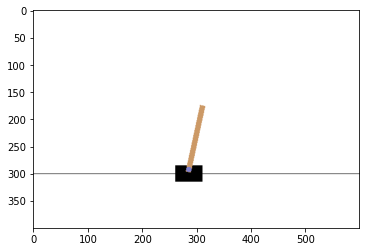

In [ ]:
# 무작위 행동으로 한 에피소드 실행 후 한 장면 출력 (gymnasium API)
demo_env = gym.make('CartPole-v1', render_mode='rgb_array')
obs, info = demo_env.reset(seed=0)
frame = demo_env.render()
for i in range(100):
    action = demo_env.action_space.sample()
    obs, reward, terminated, truncated, info = demo_env.step(action)
    frame = demo_env.render()
    if terminated or truncated:
        break
demo_env.close()

plt.figure(figsize=(6, 4))
plt.imshow(frame); plt.axis('off')
plt.title(f'무작위 행동: {i+1} step 후 막대가 쓰러짐')
plt.show()

## Q-Learning 학습


### Q-Learning 핵심 루프 살펴보기

각 에피소드마다 환경을 초기화하고, 매 timestep 마다 **ε-greedy** 로 행동을 선택해 환경에 적용한 뒤, 받아온 `(reward, next_state)` 로 Q-Table 한 칸을 업데이트합니다.

**Q-Learning 업데이트 식**

$$Q(s, a) \leftarrow Q(s, a) + \alpha \big[\, r + \gamma \max_{a'} Q(s', a') - Q(s, a) \,\big]$$

| 기호 | 코드 | 의미 |
|---|---|---|
| α (alpha) | `learning_rate` | 학습률 — 새 정보를 얼마나 반영할지 |
| γ (gamma) | `dis` | 감쇄계수 — 미래 보상의 현재가치 |
| ε (epsilon) | `e` | 탐험 확률 — 작아질수록 정책에 의존 |
| `maxQ` | `np.amax(Q_Table[new_state])` | 다음 상태의 최대 Q값 (TD target) |

**진행에 따른 스케줄**
- `e = 1./(i//20 + 1)` — 에피소드가 진행될수록 ε 감소 → 탐험 ↓ / 이용 ↑
- `learning_rate = df * learning_rate_init` — 학습률도 함께 감소 → 후반에는 미세조정

**종료 조건**
- 한 에피소드에서 `t >= num_success` (199 step 유지) 면 “성공 1회”
- `num_streaks > streak_num_success` (100 회 연속 성공) 시 학습 종료

In [ ]:
num_streaks = 0
episode_rewards = []

for i in range(num_episodes):
    obs, info = env.reset(seed=i)
    state = state_to_table(obs)

    e = get_rate(i)             # 탐험률 (ε)
    learning_rate = get_rate(i)

    total_reward = 0
    for t in range(max_trial):
        # ε-greedy 행동 선택
        if np.random.rand() < e:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q_Table[state]))

        # 환경 진행 (gymnasium: 5개 반환값)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        new_state = state_to_table(obs)

        # Q-Learning 업데이트
        best_next = np.amax(Q_Table[new_state])
        Q_Table[state + (action,)] += learning_rate * (
            reward + gamma * best_next - Q_Table[state + (action,)]
        )

        state = new_state
        total_reward += reward
        if done:
            num_streaks = num_streaks + 1 if t >= num_success else 0
            break

    episode_rewards.append(total_reward)
    if (i + 1) % 25 == 0:
        print(f'Episode {i+1}/{num_episodes}  최근25평균={np.mean(episode_rewards[-25:]):6.1f}  '
              f'streaks={num_streaks}  e={e:.3f}')

    if num_streaks > streak_num_success:
        print(f'\n학습 성공! {i+1} 에피소드에서 {streak_num_success}회 연속 성공')
        break

env.close()

# 학습 곡선
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.4, label='에피소드 보상')
if len(episode_rewards) >= 25:
    ma = np.convolve(episode_rewards, np.ones(25) / 25, mode='valid')
    plt.plot(range(24, len(episode_rewards)), ma, color='red', label='25 이동평균')
plt.xlabel('에피소드'); plt.ylabel('총 보상 (버틴 step 수)')
plt.title('CartPole Q-Learning 학습 곡선')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

KeyboardInterrupt: ignored

Error in callback <function flush_figures at 0x7ff49c49e840> (for post_execute):


KeyboardInterrupt: ignored